This is the code for the final project in ECSE 343: Numerical Methods for Engs. Our team, group 20, is made up of
- Serge Al Laham
- Emily Wang
- Jeremias Zimmerman
- Steven Thao

# Part 1: Data generation

# 1.1 Dataset generation

Creating dataset...


  0%|          | 0/30000 [00:00<?, ?it/s]

Dataset created successfully


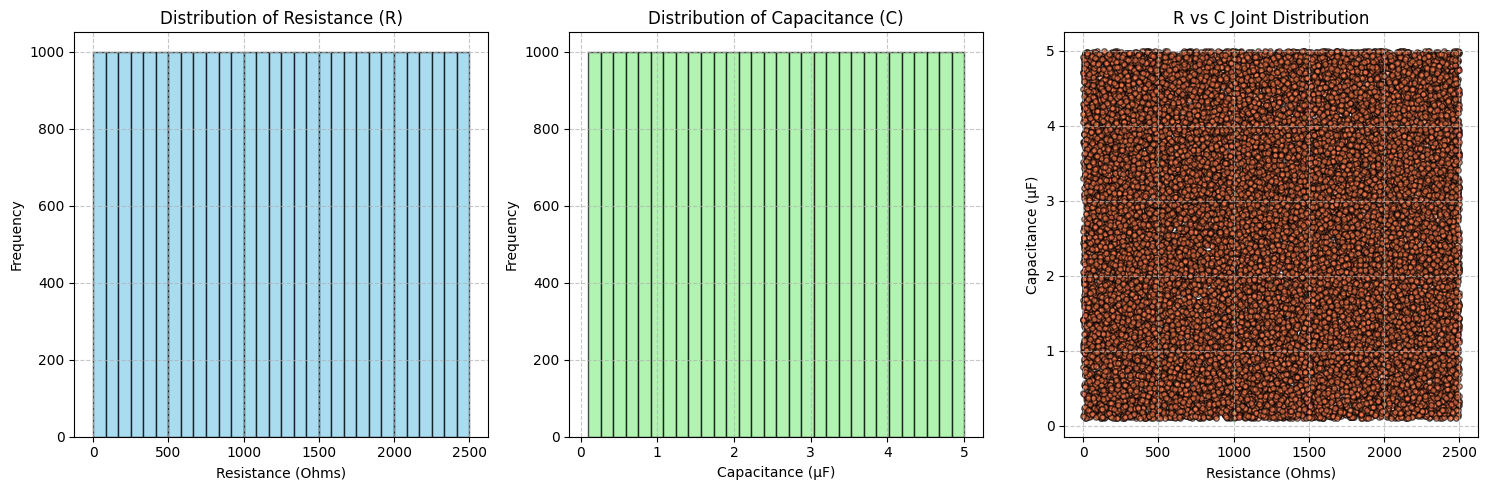

In [51]:
import importlib
import helper_functions
importlib.reload(helper_functions)
from helper_functions import create_dataset, plot_rc_distribution

# variables
num_samples = 30000
amplitude = 5.0
f = 60.0
delta_t = 0.0001
T = 0.05
noise = 0.1

dataset_x, dataset_y = create_dataset(num_samples, amplitude, f, delta_t, T, noise)
plot_rc_distribution(dataset_y)

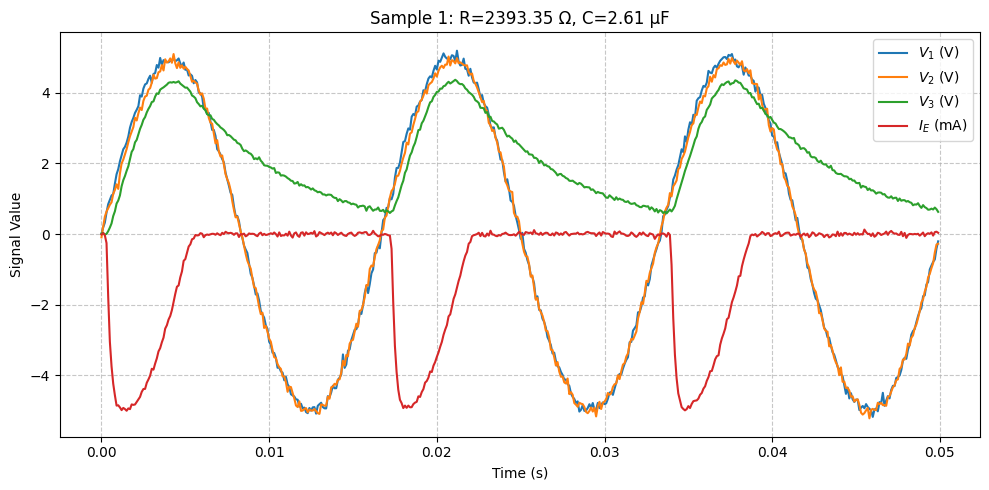

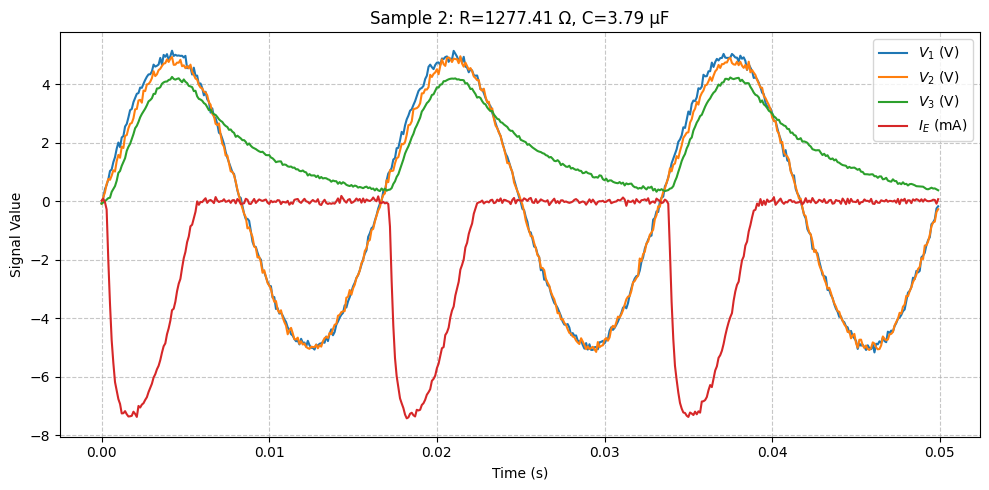

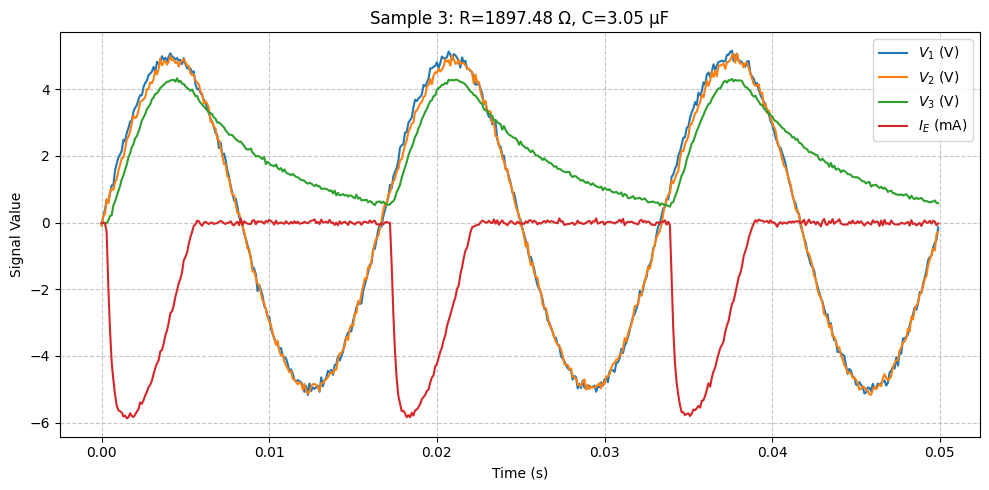

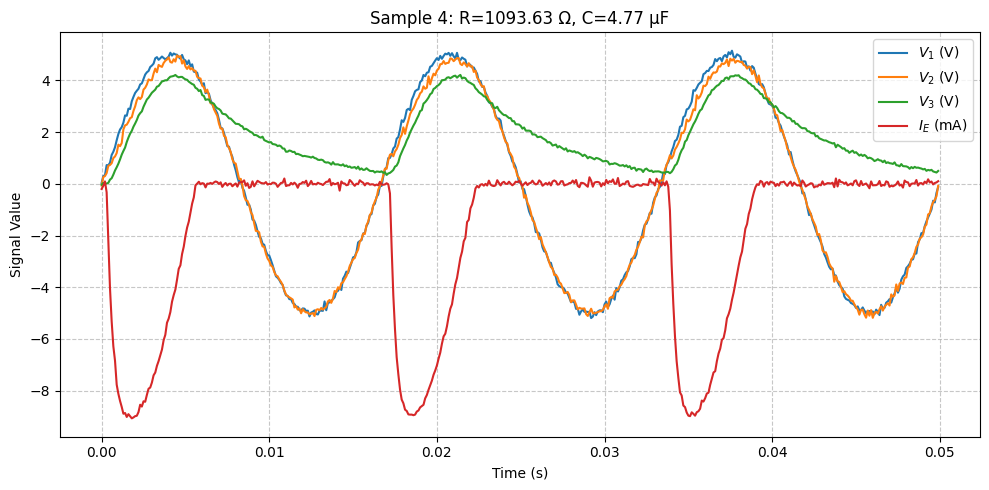

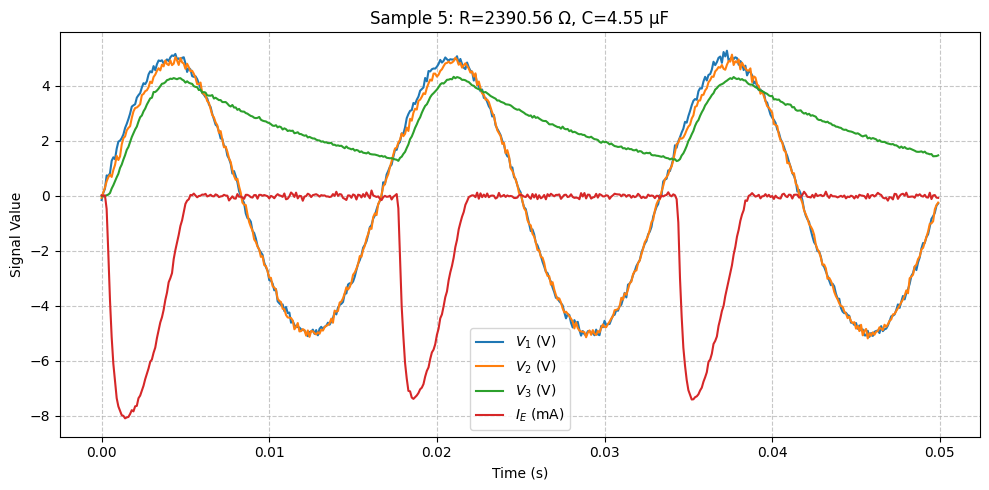

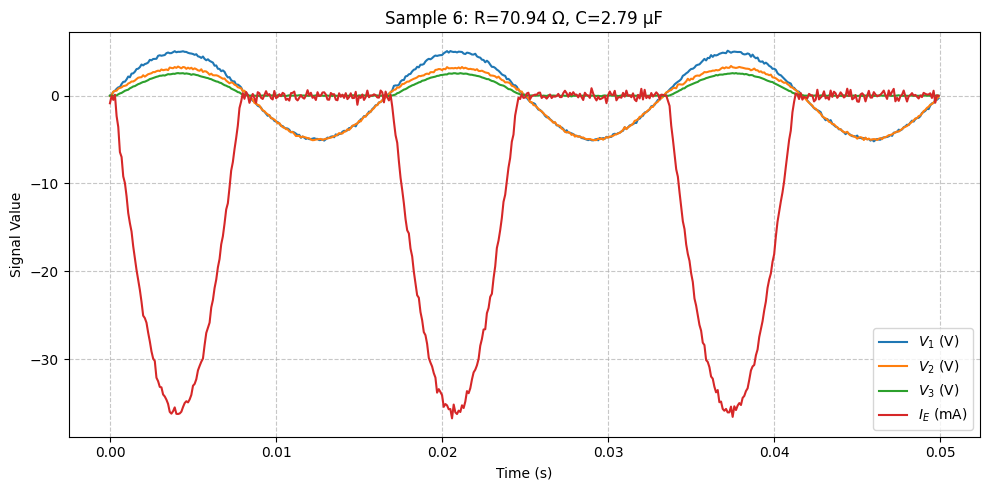

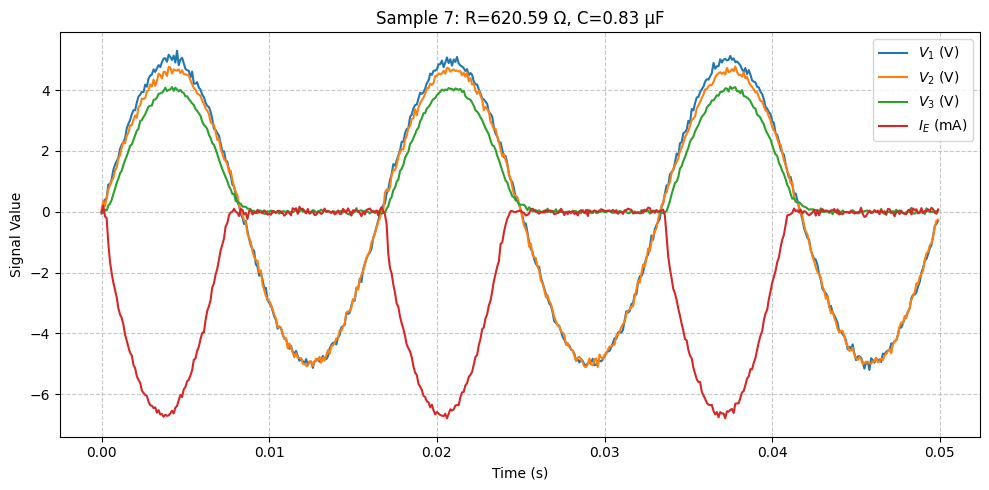

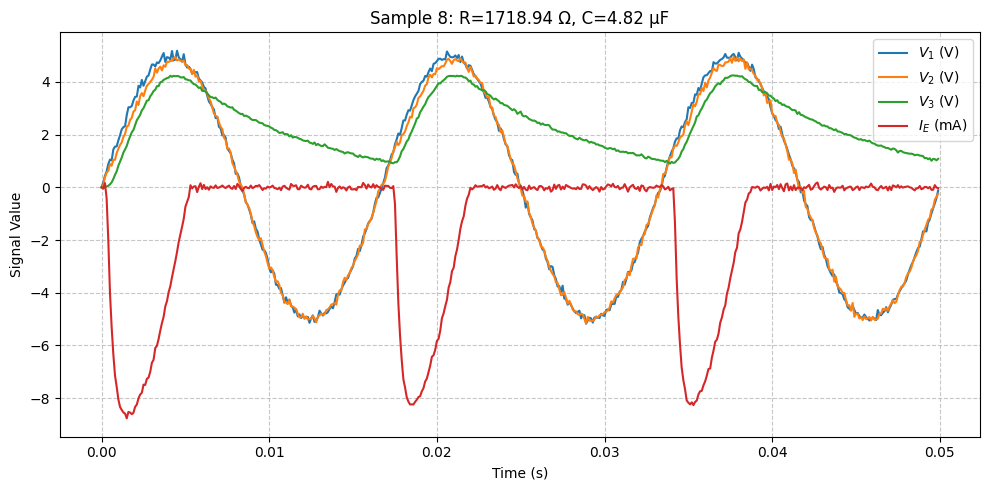

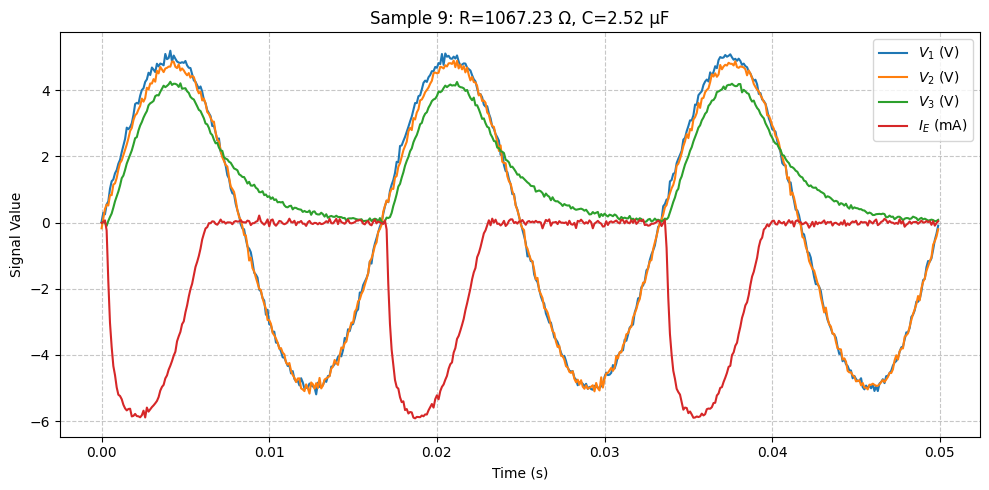

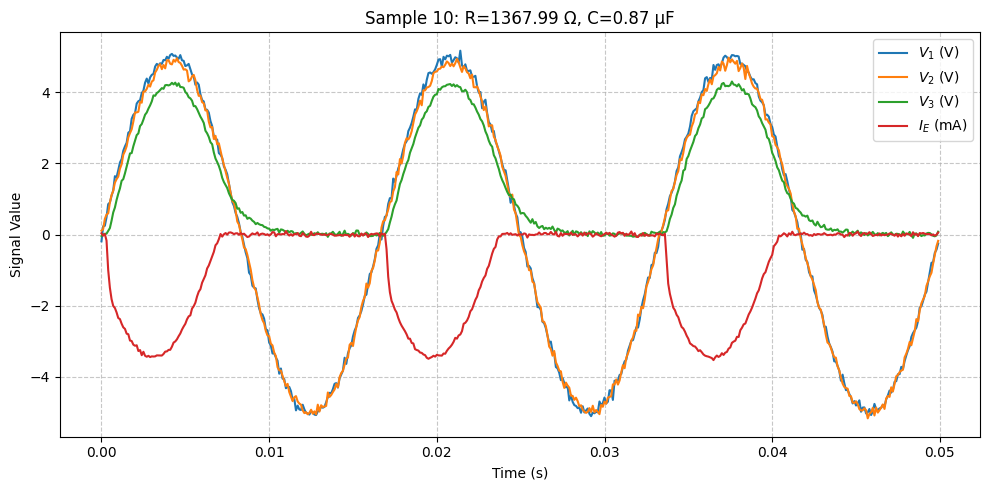

In [2]:
# Plotting sample signals
import numpy as np
import matplotlib.pyplot as plt

random_samples_idx = np.random.randint(0, num_samples, 10)
random_samples = dataset_x[random_samples_idx]
random_samples_y = dataset_y[random_samples_idx]

tpoints = np.arange(dataset_x.shape[1]) * delta_t
signal_names = [r"$V_1$ (V)", r"$V_2$ (V)", r"$V_3$ (V)", r"$I_E$ (mA)"]

for i, (sample, label) in enumerate(zip(random_samples, random_samples_y)):
    plt.figure(figsize=(10, 5))
    for j in range(4):
        plt.plot(tpoints, sample[:, j], label=signal_names[j])
    plt.xlabel("Time (s)")
    plt.ylabel("Signal Value")
    plt.title(f"Sample {i+1}: R={np.exp(label[0]):.2f} Ω, C={np.exp(label[1])*1e6:.2f} μF")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 1.2 Data Pre-processing (FFT)

In [52]:
import numpy as np
from tqdm.auto import tqdm

def calibrate_variance(x: np.ndarray, top_k_23: int = 10) -> dict:
    """
    Select frequency bins by per-bin magnitude variance across the full training dataset.

    Bins with high cross-sample variance carry the most discriminative information
    about R and C. This is more principled than selecting bins from a single reference
    measurement, where peak magnitude does not imply discriminative power — a bin can
    dominate one measurement yet be nearly constant across the whole dataset (making it
    a useless feature). Variance-selected bins, by contrast, change precisely because
    R and C change, which is what the model needs to learn from.

    Index convention (matches get_feature_vector):
      - ch 0, 1: indices are 1-based full-spectrum indices, used with the unsliced
                 FFT row as row[i].
      - ch 2, 3: indices are 0-based AC indices (DC already stripped), used with
                 ac_mag = row[1:] as ac_mag[i].  No +1 shift here.

    Input:
        x:        Training dataset, shape (N, T, 4)
        top_k_23: Number of top AC bins to select for channels 2 and 3
    Returns:
        dict mapping channel index -> locked bin index (int or 1-D int array)
    """
    N, T, n_channels = x.shape
    spectra = np.fft.rfft(x, axis=1) # (N, bins, 4)
    mags = np.abs(spectra) # (N, bins, 4)

    mag_var = mags.var(axis=0) # (bins, 4) — variance across N samples

    indices = {}
    print("Calibrating via variance across training set...")
    for ch in tqdm(range(n_channels)):
        ac_var = mag_var[1:, ch]        # exclude DC bin (index 0); shape (bins-1,)
        if ch < 2:
            # +1 shifts from 0-based AC position to 1-based full-spectrum index,
            # because get_feature_vector reads row[i] on the unsliced FFT output.
            top_idx = int(np.argmax(ac_var)) + 1
            indices[ch] = top_idx
        else:
            # No +1 shift: get_feature_vector accesses ac_mag = row[1:] using these
            # indices directly (0-based into the AC portion).
            top_k_idx = np.argsort(ac_var)[::-1][:top_k_23]
            indices[ch] = top_k_idx

    return indices


def get_feature_vector(x: np.ndarray, indices: dict) -> np.ndarray:
    """
    Build the feature vector using the locked bin indices from calibrate_variance().
    Layout: [mag_11, ph_11, mag_21, ph_21,
             DC_3, mag_31, ph_31, ..., ph_35,
             DC_4, mag_41, ph_41, ..., ph_45] -> shape (46,)

    Input:
        x:       Single sample, shape (T, 4)
        indices: dict from calibrate_variance()
    Output:
        feature_vector: numpy array of shape (46,)
    """
    signals = x.T                           # (4, T)
    features = np.fft.rfft(signals, axis=1) # (4, bins)

    feature_vector = []

    for idx, row in enumerate(features):
        if idx < 2:
            i = indices[idx]
            feature_vector += [np.abs(row[i]), np.angle(row[i])]
        else:
            dc = np.abs(row[0])
            ac_mag = np.abs(row[1:])
            ac_phs = np.angle(row[1:])

            feature_vector.append(dc)
            for i in indices[idx]:
                feature_vector += [ac_mag[i], ac_phs[i]]

    return np.array(feature_vector)


# Calibrate using full training dataset variance — not a single reference file
indices = calibrate_variance(dataset_x)

# Build feature matrix
feature_matrix = []
print("Building feature matrix...")
for sample in tqdm(dataset_x):
    feature_matrix.append(get_feature_vector(sample, indices))

feature_matrix = np.array(feature_matrix)

Calibrating via variance across training set...


  0%|          | 0/4 [00:00<?, ?it/s]

Building feature matrix...


  0%|          | 0/30000 [00:00<?, ?it/s]

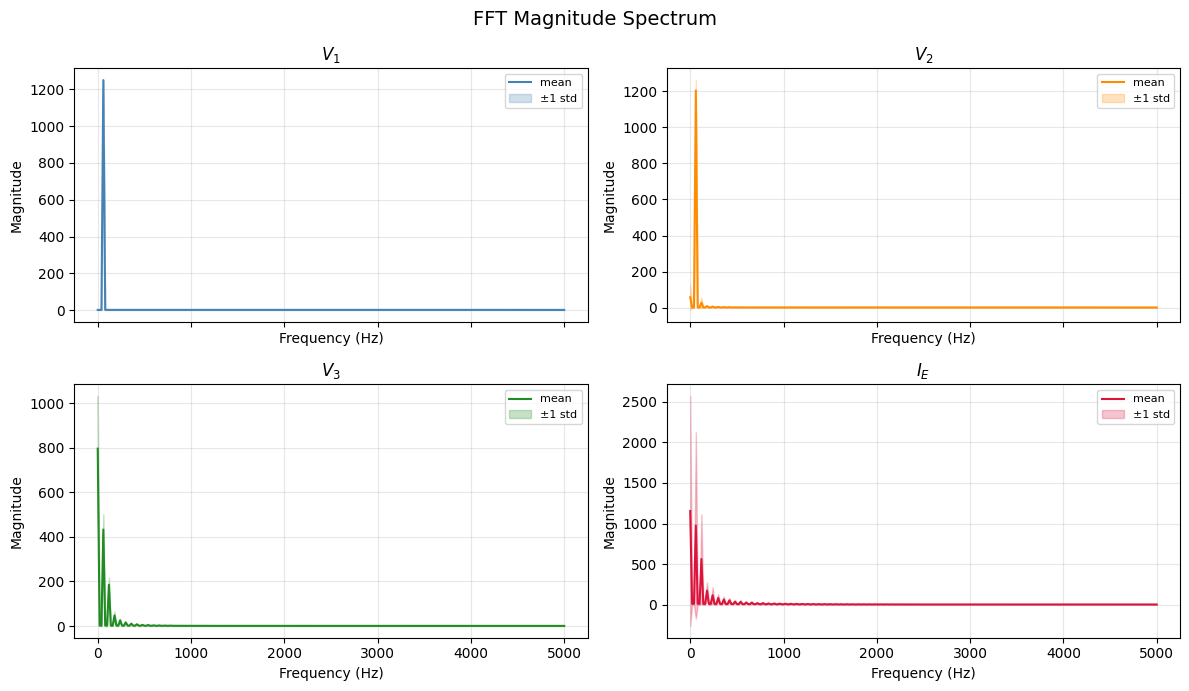

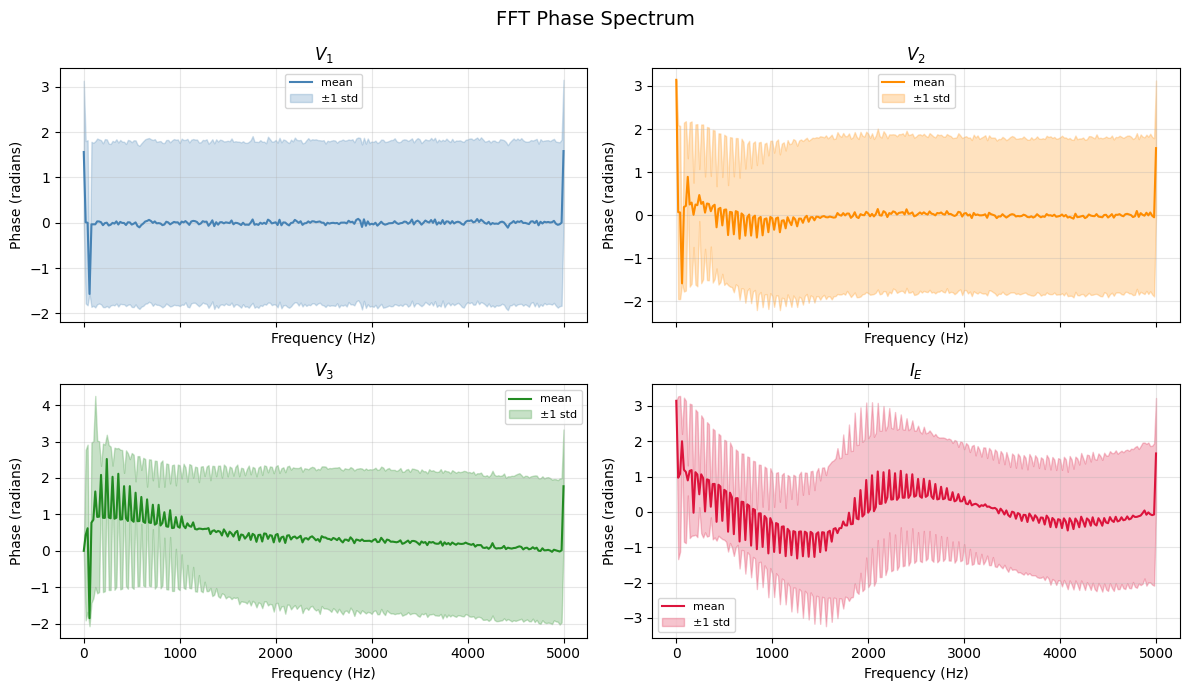

In [90]:
def plot_fft_spectrum(x: np.ndarray, delta_t: float = None):
    """
    Plot magnitude and phase spectra across every frequency bin for all samples.

    For each of the 4 channels, shows the mean spectrum with a ±1 std envelope
    computed over the whole dataset.

    Input:
        x:       Raw time-domain dataset, shape (N, T, 4)
        delta_t: Sampling interval in seconds. If provided, x-axis is shown in Hz;
                 otherwise raw bin indices are used.
    """
    N, T, n_channels = x.shape
    spectra = np.fft.rfft(x, axis=1)          # (N, T//2+1, 4)
    mags    = np.abs(spectra)                  # (N, bins, 4)
    phases  = np.angle(spectra)                # (N, bins, 4)

    n_bins = mags.shape[1]
    freq_axis = np.fft.rfftfreq(T, d=delta_t) if delta_t is not None else np.arange(n_bins)
    x_label   = "Frequency (Hz)" if delta_t is not None else "Frequency bin"

    signal_names = [r"$V_1$", r"$V_2$", r"$V_3$", r"$I_E$"]
    colors       = ["steelblue", "darkorange", "forestgreen", "crimson"]

    for data, ylabel, title in [
        (mags,   "Magnitude",       "FFT Magnitude Spectrum"),
        (phases, "Phase (radians)", "FFT Phase Spectrum"),
    ]:
        fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
        fig.suptitle(title, fontsize=14)

        for ch, ax in enumerate(axes.flat):
            mean = data[:, :, ch].mean(axis=0)   # (bins,)
            std  = data[:, :, ch].std(axis=0)    # (bins,)

            ax.plot(freq_axis, mean, color=colors[ch], linewidth=1.5, label="mean")
            ax.fill_between(
                freq_axis,
                mean - std,
                mean + std,
                color=colors[ch], alpha=0.25, label="±1 std"
            )
            ax.set_title(signal_names[ch])
            ax.set_ylabel(ylabel)
            ax.set_xlabel(x_label)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)

        plt.tight_layout()
        plt.show()

plot_fft_spectrum(dataset_x, delta_t=delta_t)

# Part 2: Newton-Raphson method

# Part 3: ML solution

In [53]:
# imports
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [54]:
"""
    Base class for multivariate polynomial regression
"""
class PolyReg(nn.Module):
    def __init__(self, degree: int, lr: float = 0.001):
        super().__init__()
        self.degree = degree
        self.hidden = nn.Linear(46 * degree, 2)
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        poly_features = [x ** i for i in range(1, self.degree + 1)]
        poly_features = torch.cat(poly_features, dim=-1)
        return self.hidden(poly_features)

    """
    Trains the model.

    Input:
        x_train: N x 26 matrix of all training inputs
        y_train: N x 2 matrix of all training labels
        epochs: Training epochs
    Output:
        None
    """
    def fit(self, x_train, y_train, epochs=100, batch_size=64, x_val=None, y_val=None):
        train_loader = DataLoader(
            TensorDataset(x_train, y_train),
            batch_size=batch_size, shuffle=True
        )
        train_losses = []
        val_losses = [] if x_val is not None and y_val is not None else None
        pbar = tqdm(range(epochs), desc="Training", unit="epoch")
        for epoch in pbar:
            self.train()
            epoch_loss = 0.0
            for x_batch, y_batch in train_loader:
                self.optimizer.zero_grad()
                outputs = self.forward(x_batch)
                loss = self.loss_fn(outputs, y_batch)
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item() * x_batch.size(0)
            train_loss = epoch_loss / len(x_train)
            train_losses.append(train_loss)
            postfix = {"train_loss": f"{train_loss:.4f}"}
            if val_losses is not None:
                val_loss = self.val_test(x_val, y_val)
                val_losses.append(val_loss)
                postfix["val_loss"] = f"{val_loss:.4f}"
            pbar.set_postfix(postfix)
        return train_losses, val_losses

    """
        Obtains the test score for the model.

        Input:
            x_test: N x 26 matrix of all test inputs
            y_test: N x 2 matrix of all test labels
        Output:
            resul: validation accuracy for the current test set
    """
    def val_test(self, x_test: torch.Tensor, y_test: torch.Tensor) -> float:
        self.eval()
        total_loss = 0.0
        loader = DataLoader(TensorDataset(x_test, y_test), batch_size=256, shuffle=False)
        with torch.no_grad():
            for x_batch, y_batch in loader:
                pred = self.forward(x_batch)
                loss = self.loss_fn(pred, y_batch)
                total_loss += loss.item() * x_batch.size(0)
        self.train()
        return total_loss / len(x_test)

In [90]:
"""
    Class for simple feedforward neural network.
"""
class NeuralNet(nn.Module):
    """
    For now, the activation function is ReLU. Can adapt to other functions in the future.

    Input:
        units: list of number of units in each layer, including input and output layers.
        lr: learning rate for Adam optimizer.
    Output:
        NeuralNet object.
    """
    def __init__(self, units: list[int], lr: float = 0.001, dropout_rate: float = 0.0) -> None:
        super().__init__()
        self.hidden = nn.ModuleList([nn.Linear(units[i], units[i + 1]) for i in range(len(units) - 1)])
        self.activation = nn.ReLU()
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.hidden[:-1]:
            x = self.activation(layer(x))
        return self.hidden[-1](x)

    """
    Trains the model.

    Input:
        x_train: N x 26 matrix of all training inputs
        y_train: N x 2 matrix of all training labels
        epochs: Training epochs
    Output:
        None
    """
    def fit(self, x_train, y_train, epochs=100, batch_size=64, x_val=None, y_val=None):
        train_loader = DataLoader(
            TensorDataset(x_train, y_train),
            batch_size=batch_size, shuffle=True
        )
        train_losses = []
        val_losses = [] if x_val is not None and y_val is not None else None
        pbar = tqdm(range(epochs), desc="Training", unit="epoch")
        for epoch in pbar:
            self.train()
            epoch_loss = 0.0
            for x_batch, y_batch in train_loader:
                self.optimizer.zero_grad()
                outputs = self.forward(x_batch)
                loss = self.loss_fn(outputs, y_batch)
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item() * x_batch.size(0)
            train_loss = epoch_loss / len(x_train)
            train_losses.append(train_loss)
            postfix = {"train_loss": f"{train_loss:.4f}"}
            if val_losses is not None:
                val_loss = self.val_test(x_val, y_val)
                val_losses.append(val_loss)
                postfix["val_loss"] = f"{val_loss:.4f}"
            pbar.set_postfix(postfix)
        return train_losses, val_losses


    """
        Obtains the test score for the model.

        Input:
            x_test: N x 26 matrix of all test inputs
            y_test: N x 2 matrix of all test labels
        Output:
            resul: validation accuracy for the current test set
    """
    def val_test(self, x_test: torch.Tensor, y_test: torch.Tensor) -> float:
        self.eval()
        total_loss = 0.0
        loader = DataLoader(TensorDataset(x_test, y_test), batch_size=256, shuffle=False)
        with torch.no_grad():
            for x_batch, y_batch in loader:
                pred = self.forward(x_batch)
                loss = self.loss_fn(pred, y_batch)
                total_loss += loss.item() * x_batch.size(0)
        self.train()
        return total_loss / len(x_test)

    def relative_error(self, x_test: torch.Tensor, y_test: torch.Tensor) -> np.ndarray:
        """
        Compute mean absolute relative error (%) per output over the test set.

        Input:
            x_test: N x input_dim tensor
            y_test: N x output_dim tensor
        Output:
            mre: 1-D numpy array of shape (output_dim,) with per-output mean relative errors in %.
        """
        self.eval()
        with torch.no_grad():
            preds = self.forward(x_test).numpy()  # (N, output_dim)
        self.train()

        targets = y_test.numpy()         # (N, output_dim)
        rel_errors = np.abs(preds - targets) / (np.abs(targets) + 1e-12) * 100.0
        return rel_errors.mean(axis=0)   # (output_dim,)

In [91]:
def split_dataset(dataset: tuple[torch.Tensor, torch.Tensor], train_ratio: float = 0.7, val_ratio: float = 0.15) -> tuple[tuple[torch.Tensor, torch.Tensor], tuple[torch.Tensor, torch.Tensor], tuple[torch.Tensor, torch.Tensor]]:
    """
    Split dataset into training, validation, and test sets.

    Input:
        dataset: single tuple of (X, y) where X is all the input data and y is all the labels.
        train_ratio: decimal ratio of training data.
        val_ratio: decimal ratio of validation data.
    Output:
        tuple of (X_train, y_train), (X_val, y_val), (X_test, y_test) where X and y are torch tensors.
    """
    X, y = dataset
    n_samples = X.shape[0]
    # shuffle indices
    indices = np.random.permutation(n_samples)
    # calculate split indices
    train_end = int(train_ratio * n_samples)
    val_end = int((train_ratio + val_ratio) * n_samples)

    # do the split
    X_train, y_train = X[indices[:train_end]], y[indices[:train_end]]
    X_val, y_val = X[indices[train_end:val_end]], y[indices[train_end:val_end]]
    X_test, y_test = X[indices[val_end:]], y[indices[val_end:]]

    return (torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)), (torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32)), (torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

dataset = (feature_matrix, dataset_y)
D_train, D_val, D_test = split_dataset(dataset, train_ratio=0.85, val_ratio=0.15)
print("Training set:", D_train[0].shape, D_train[1].shape)
print("Validation set:", D_val[0].shape, D_val[1].shape)
print("Test set:", D_test[0].shape, D_test[1].shape)

x_mean = D_train[0].mean(dim=0)
x_std = D_train[0].std(dim=0) + 1e-8
y_mean = D_train[1].mean(dim=0)
y_std = D_train[1].std(dim=0) + 1e-8

D_train = ((D_train[0] - x_mean) / x_std, (D_train[1] - y_mean) / y_std)
D_val = ((D_val[0] - x_mean) / x_std, (D_val[1] - y_mean) / y_std)
D_test = ((D_test[0] - x_mean) / x_std, (D_test[1] - y_mean) / y_std)

data = pd.read_csv("../data/measurements.csv", header=None).to_numpy(dtype=np.float64)
data[:, 3] *= 1000
feature_vec = get_feature_vector(data, indices)
feature_vec = torch.tensor(feature_vec, dtype=torch.float32)
pred_x = ((feature_vec - x_mean) / x_std).unsqueeze(0)  # (1, 46)

Training set: torch.Size([25500, 46]) torch.Size([25500, 2])
Validation set: torch.Size([4500, 46]) torch.Size([4500, 2])
Test set: torch.Size([0, 46]) torch.Size([0, 2])



Training polynomial regression 5 times...
Run 1


Training:   0%|          | 0/400 [00:00<?, ?epoch/s]

Run 2


Training:   0%|          | 0/400 [00:00<?, ?epoch/s]

Run 3


Training:   0%|          | 0/400 [00:00<?, ?epoch/s]

Run 4


Training:   0%|          | 0/400 [00:00<?, ?epoch/s]

Run 5


Training:   0%|          | 0/400 [00:00<?, ?epoch/s]

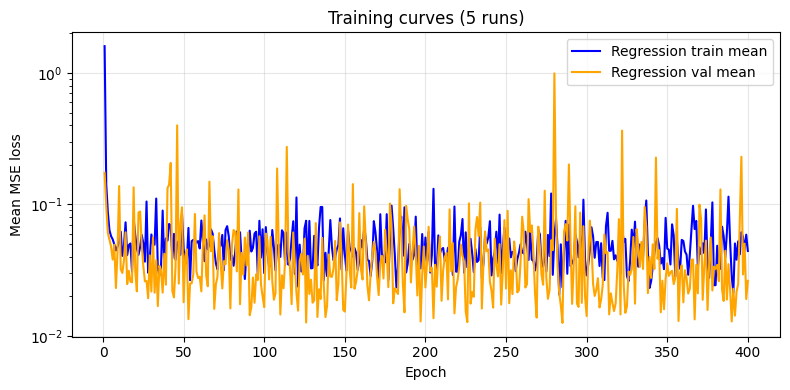

In [60]:
num_runs = 5
epochs = 400

all_poly_train = []
all_poly_val = []
predictions = []

print(f"\nTraining polynomial regression {num_runs} times...")

# 3. Train neural network multiple times
for run in range(1, num_runs + 1):
    print(f"Run {run}")
    regression = PolyReg(degree=3)
    poly_train, poly_val = regression.fit(
        D_train[0], D_train[1], epochs=epochs, x_val=D_val[0], y_val=D_val[1]
    )
    all_poly_train.append(poly_train)
    if poly_val is not None:
        all_poly_val.append(poly_val)
    
    with torch.no_grad():
        log_pred = regression(pred_x)
        log_pred = log_pred * y_std + y_mean
        pred = torch.exp(log_pred)

        R_pred, C_pred = pred[0, 0].item(), pred[0, 1].item()
        predictions.append((R_pred, C_pred))

# Convert to numpy arrays to compute mean and std
all_poly_train = np.array(all_poly_train)
all_poly_val = np.array(all_poly_val) if len(all_poly_val) > 0 else None

train_mean = all_poly_train.mean(axis=0)

if all_poly_val is not None:
    val_mean = all_poly_val.mean(axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
epochs_poly = range(1, epochs + 1)

ax.plot(epochs_poly, train_mean, label="Regression train mean", color='blue')

if all_poly_val is not None:
    ax.plot(epochs_poly, val_mean, label="Regression val mean", color='orange')

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean MSE loss")
ax.set_yscale("log")
ax.set_title(f"Training curves ({num_runs} runs)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

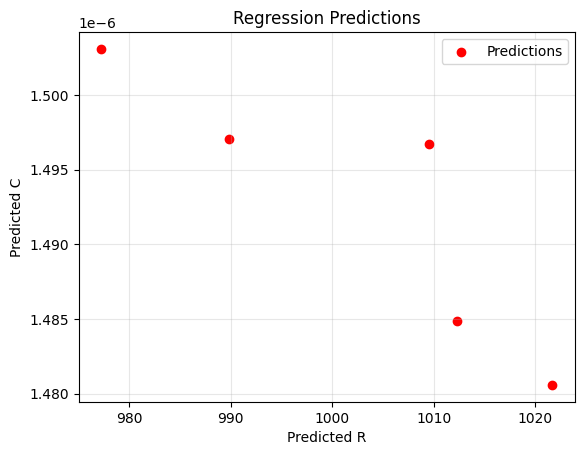

In [61]:
import matplotlib.pyplot as plt

plt.scatter(
    [pred[0] for pred in predictions],
    [pred[1] for pred in predictions],
    color='red', label='Predictions'
)
plt.xlabel("Predicted R")
plt.ylabel("Predicted C")
plt.title("Regression Predictions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
avg = np.sum(np.array(predictions), axis=0) / len(predictions)
print(f"Average R: {avg[0]:.4f}, Average C: {avg[1]}")

Average R: 1002.1121, Average C: 1.4924638435331873e-06


Training set: torch.Size([25500, 46]) torch.Size([25500, 2])
Validation set: torch.Size([4500, 46]) torch.Size([4500, 2])
Test set: torch.Size([0, 46]) torch.Size([0, 2])

Training Neural Network 5 times for confidence intervals...
Run 1


Training:   0%|          | 0/400 [00:00<?, ?epoch/s]

Run 2


Training:   0%|          | 0/400 [00:00<?, ?epoch/s]

Run 3


Training:   0%|          | 0/400 [00:00<?, ?epoch/s]

Run 4


Training:   0%|          | 0/400 [00:00<?, ?epoch/s]

Run 5


Training:   0%|          | 0/400 [00:00<?, ?epoch/s]

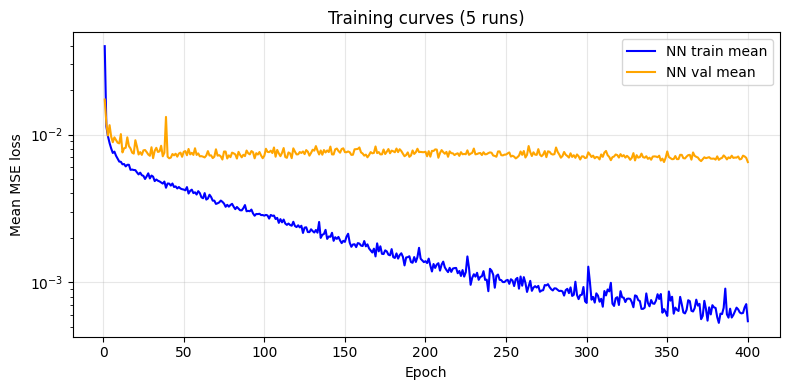

In [ ]:
units = [46, 256, 64, 2] # 46 inputs, 3 hidden layers, 2 outputs
num_runs = 5
epochs = 400

all_nn_train = []
all_nn_val = []
predictions = []

print(f"\nTraining Neural Network {num_runs} times...")

# 3. Train neural network multiple times
for run in range(1, num_runs + 1):
    print(f"Run {run}")
    network = NeuralNet(units, lr=0.001)
    nn_train, nn_val = network.fit(
        D_train[0], D_train[1], epochs=epochs, x_val=D_val[0], y_val=D_val[1]
    )
    all_nn_train.append(nn_train)
    if nn_val is not None:
        all_nn_val.append(nn_val)
    
    with torch.no_grad():
        log_pred = network(pred_x)
        log_pred = log_pred * y_std + y_mean
        pred = torch.exp(log_pred)

        R_pred, C_pred = pred[0, 0].item(), pred[0, 1].item()
        predictions.append((R_pred, C_pred))

# Convert to numpy arrays to compute mean and std
all_nn_train = np.array(all_nn_train)
all_nn_val = np.array(all_nn_val) if len(all_nn_val) > 0 else None

train_mean = all_nn_train.mean(axis=0)

if all_nn_val is not None:
    val_mean = all_nn_val.mean(axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
epochs_nn = range(1, epochs + 1)

ax.plot(epochs_nn, train_mean, label="NN train mean", color='blue')

if all_nn_val is not None:
    ax.plot(epochs_nn, val_mean, label="NN val mean", color='orange')

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean MSE loss")
ax.set_yscale("log")
ax.set_title(f"Training curves ({num_runs} runs)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

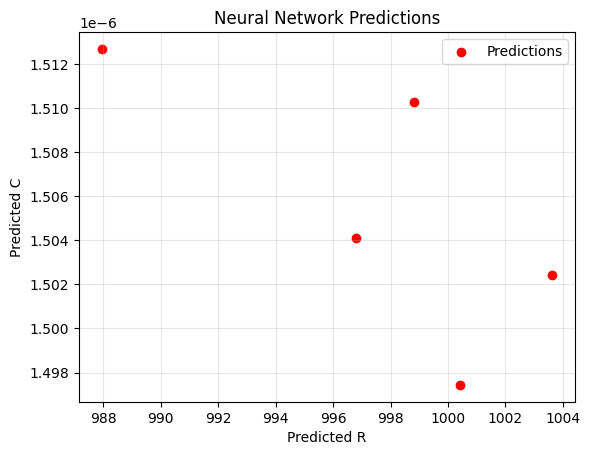

In [100]:
import matplotlib.pyplot as plt

plt.scatter(
    [pred[0] for pred in predictions],
    [pred[1] for pred in predictions],
    color='red', label='Predictions'
)
plt.xlabel("Predicted R")
plt.ylabel("Predicted C")
plt.title("Neural Network Predictions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()